# Testes de Modelagem da Comunidade

Este notebook analisa `recommendations.csv` para orientar a modelagem da componente de comunidade do projeto.

A ideia aqui e explorar a distribuicao das interacoes, testar filtros candidatos e registrar evidencias antes de consolidar decisoes e mover a logica para um script reproduzivel.

In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_PATH = BASE_DIR / "data" / "raw" / "recommendations.csv"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

assert DATA_PATH.exists(), f"Arquivo nao encontrado: {DATA_PATH}"


## 1. Leitura da base

Comecamos carregando o CSV bruto de recomendacoes. A leitura abaixo preserva a inferencia padrao do pandas para inspecionar o esquema real encontrado no arquivo.

In [3]:
df = pd.read_csv(DATA_PATH)

print(DATA_PATH)
print(f"Linhas: {len(df):,}")
display(df.head())


/home/guilherme/mc859/data/raw/recommendations.csv
Linhas: 41,154,794


,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,975370,0,0,2022-12-12,True,36.3,51580,0
1,304390,4,0,2017-02-17,False,11.5,2586,1
2,1085660,2,0,2019-11-17,True,336.5,253880,2
3,703080,0,0,2022-09-23,True,27.4,259432,3
4,526870,0,0,2021-01-10,True,7.9,23869,4


## 2. Esquema e qualidade basica

Nesta etapa listamos colunas, tipos inferidos e quantidade de valores nulos para validar o formato antes de discutir filtros.

In [4]:
schema_df = pd.DataFrame({
    "coluna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "pct_nulos": (df.isna().mean().values * 100).round(4),
})

display(schema_df)


,coluna,tipo,nulos,pct_nulos
0,app_id,int64,0,0.0
1,helpful,int64,0,0.0
2,funny,int64,0,0.0
3,date,str,0,0.0
4,is_recommended,bool,0,0.0
5,hours,float64,0,0.0
6,user_id,int64,0,0.0
7,review_id,int64,0,0.0


## 3. Escala da base

Calculamos agora o tamanho efetivo da interacao usuario-jogo: quantidade de usuarios distintos, jogos distintos e total de interacoes registradas.

In [5]:
summary_df = pd.DataFrame([
    {
        "usuarios_distintos": df["user_id"].nunique(),
        "jogos_distintos": df["app_id"].nunique(),
        "interacoes_totais": len(df),
    }
])

display(summary_df)


,usuarios_distintos,jogos_distintos,interacoes_totais
0,13781059,37610,41154794


## 4. Distribuicao de interacoes por jogo

Aqui agrupamos por `app_id` para entender quantas interacoes cada jogo recebe. O histograma ajuda a visualizar cauda longa, enquanto os quantis e cortes `<5`, `<10` e `<20` mostram o efeito de filtros minimos por jogo.

,quantil,valor
0,0.50,39.00
1,0.75,179.75
2,0.90,969.10
3,0.99,23476.19


,criterio,quantidade
0,jogos com <5 interacoes,2012
1,jogos com <10 interacoes,6384
2,jogos com <20 interacoes,12993


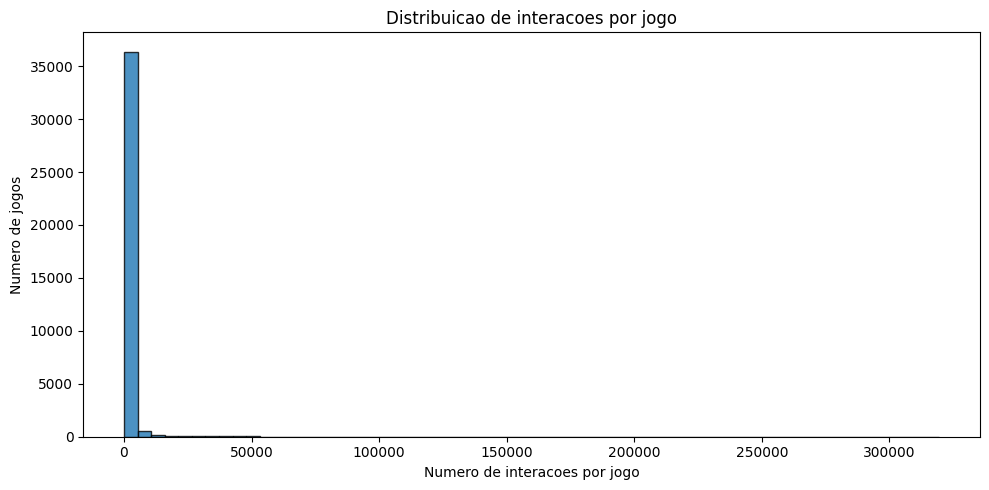

In [6]:
interactions_per_game = df.groupby("app_id").size().rename("interacoes")

game_quantiles = interactions_per_game.quantile([0.50, 0.75, 0.90, 0.99]).rename_axis("quantil").reset_index(name="valor")
game_thresholds_df = pd.DataFrame([
    {"criterio": "jogos com <5 interacoes", "quantidade": int((interactions_per_game < 5).sum())},
    {"criterio": "jogos com <10 interacoes", "quantidade": int((interactions_per_game < 10).sum())},
    {"criterio": "jogos com <20 interacoes", "quantidade": int((interactions_per_game < 20).sum())},
])

display(game_quantiles)
display(game_thresholds_df)

plt.figure(figsize=(10, 5))
plt.hist(interactions_per_game, bins=60, color="#1f77b4", edgecolor="black", alpha=0.8)
plt.title("Distribuicao de interacoes por jogo")
plt.xlabel("Numero de interacoes por jogo")
plt.ylabel("Numero de jogos")
plt.tight_layout()
plt.show()


## 5. Distribuicao de jogos por usuario

Agora medimos quantos jogos distintos cada usuario avaliou. Usamos `nunique` em `app_id` por `user_id` para evitar depender implicitamente de unicidade por linha. As faixas abaixo separam usuarios muito esparsos, moderados e extremamente ativos.

Observacao: para evitar sobreposicao de intervalos, usamos as classes `1`, `2-5`, `6-20`, `21-100` e `>100`.

,quantil,valor
0,0.50,1.0
1,0.75,3.0
2,0.90,6.0
3,0.99,25.0


,faixa,usuarios
0,1 jogo,7573027
1,2-5 jogos,4733025
2,6-20 jogos,1279159
3,21-100 jogos,187653
4,>100 jogos,8195


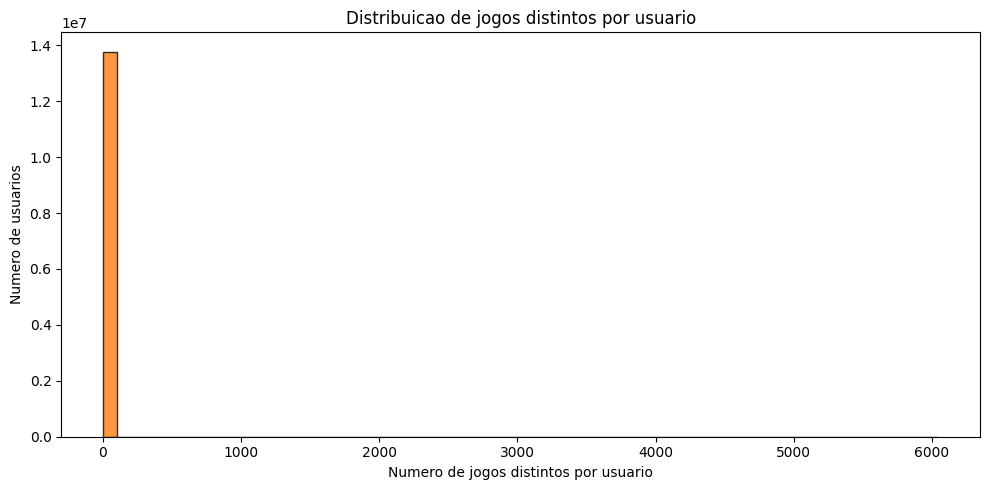

: 

In [ ]:
games_per_user = df.groupby("user_id")["app_id"].nunique().rename("jogos_distintos")

user_quantiles = games_per_user.quantile([0.50, 0.75, 0.90, 0.99]).rename_axis("quantil").reset_index(name="valor")
user_buckets_df = pd.DataFrame([
    {"faixa": "1 jogo", "usuarios": int((games_per_user == 1).sum())},
    {"faixa": "2-5 jogos", "usuarios": int(games_per_user.between(2, 5).sum())},
    {"faixa": "6-20 jogos", "usuarios": int(games_per_user.between(6, 20).sum())},
    {"faixa": "21-100 jogos", "usuarios": int(games_per_user.between(21, 100).sum())},
    {"faixa": ">100 jogos", "usuarios": int((games_per_user > 100).sum())},
])

display(user_quantiles)
display(user_buckets_df)

plt.figure(figsize=(10, 5))
plt.hist(games_per_user, bins=60, color="#ff7f0e", edgecolor="black", alpha=0.8)
plt.title("Distribuicao de jogos distintos por usuario")
plt.xlabel("Numero de jogos distintos por usuario")
plt.ylabel("Numero de usuarios")
plt.tight_layout()
plt.show()


## 6. Teste de cenarios de filtro

Nesta etapa aplicamos cada filtro isoladamente sobre a base original para medir seu impacto bruto. Isso permite comparar cortes minimos por jogo e cortes minimos/maximos por usuario antes de decidir uma combinacao definitiva.

In [ ]:
def summarize_frame(frame: pd.DataFrame, scenario: str) -> dict[str, int | str]:
    return {
        "cenario": scenario,
        "usuarios_restantes": frame["user_id"].nunique(),
        "jogos_restantes": frame["app_id"].nunique(),
        "interacoes_restantes": len(frame),
    }


game_interaction_counts = df.groupby("app_id").size()
user_game_counts = df.groupby("user_id")["app_id"].nunique()

scenarios = {
    "jogos >= 10 interacoes": df[df["app_id"].map(game_interaction_counts) >= 10],
    "jogos >= 20 interacoes": df[df["app_id"].map(game_interaction_counts) >= 20],
    "usuarios >= 2 jogos": df[df["user_id"].map(user_game_counts) >= 2],
    "usuarios <= 100 jogos": df[df["user_id"].map(user_game_counts) <= 100],
    "usuarios <= 200 jogos": df[df["user_id"].map(user_game_counts) <= 200],
}

scenario_results_df = pd.DataFrame([
    summarize_frame(frame, scenario)
    for scenario, frame in scenarios.items()
])

display(scenario_results_df)


## 7. Leitura dos resultados

Com as tabelas acima, o proximo passo do processo e escrever um relatorio curto destacando quais filtros removem ruído sem colapsar demais a cobertura de usuarios, jogos e interacoes. So depois disso vale consolidar a decisao em um script da pipeline.

## 8. Validacao do cenario combinado

Agora aplicamos simultaneamente os tres filtros candidatos para validar o cenario final antes de implementar o pipeline definitivo:

- usuarios com pelo menos 2 jogos;
- usuarios com no maximo 100 jogos;
- jogos com pelo menos 20 interacoes.

A ideia aqui e medir o tamanho final do bipartido usuario-jogo, comparar com a base original e reavaliar o risco de explosao da projecao jogo-jogo.

In [ ]:
raw_users = df["user_id"].nunique()
raw_games = df["app_id"].nunique()
raw_interactions = len(df)

combined_mask = (
    df["user_id"].map(user_game_counts).between(2, 100)
    & (df["app_id"].map(game_interaction_counts) >= 20)
)
combined_df = df.loc[combined_mask].copy()

combined_games_per_user = combined_df.groupby("user_id")["app_id"].nunique().rename("jogos_distintos")
combined_users_per_game = combined_df.groupby("app_id")["user_id"].nunique().rename("usuarios_distintos")

combined_metrics_df = pd.DataFrame([
    {
        "usuarios_distintos": combined_df["user_id"].nunique(),
        "jogos_distintos": combined_df["app_id"].nunique(),
        "interacoes_totais": len(combined_df),
        "media_jogos_por_usuario": round(combined_games_per_user.mean(), 4),
        "media_usuarios_por_jogo": round(combined_users_per_game.mean(), 4),
    }
])

display(combined_metrics_df)


## 9. Comparacao com a base original e risco de projecao

Com o dataset combinado em maos, recalculamos a cobertura preservada e a massa potencial de pares gerada pelos usuarios restantes. Essa massa e uma aproximacao direta do custo estrutural da projecao jogo-jogo, pois cada usuario com `k` jogos pode induzir ate `k * (k - 1) / 2` coocorrencias.

In [ ]:
combined_users = combined_df["user_id"].nunique()
combined_games = combined_df["app_id"].nunique()
combined_interactions = len(combined_df)

preservation_df = pd.DataFrame([
    {
        "%_usuarios_preservados": round(100 * combined_users / raw_users, 2),
        "%_jogos_preservados": round(100 * combined_games / raw_games, 2),
        "%_interacoes_preservadas": round(100 * combined_interactions / raw_interactions, 2),
    }
])

pair_mass_base = int(((user_game_counts * (user_game_counts - 1)) // 2).sum())
users_le_100_df = scenarios["usuarios <= 100 jogos"]
users_le_100_pairs = users_le_100_df.groupby("user_id")["app_id"].nunique()
pair_mass_users_le_100 = int(((users_le_100_pairs * (users_le_100_pairs - 1)) // 2).sum())
pair_mass_combined = int(((combined_games_per_user * (combined_games_per_user - 1)) // 2).sum())

pair_mass_comparison_df = pd.DataFrame([
    {"cenario": "base bruta", "massa_potencial_de_pares": pair_mass_base},
    {"cenario": "apenas usuarios <= 100", "massa_potencial_de_pares": pair_mass_users_le_100},
    {"cenario": "usuarios entre 2 e 100 + jogos >= 20", "massa_potencial_de_pares": pair_mass_combined},
])
pair_mass_comparison_df["reducao_vs_base_pct"] = (100 * (1 - pair_mass_comparison_df["massa_potencial_de_pares"] / pair_mass_base)).round(2)

display(preservation_df)
display(pair_mass_comparison_df)


## 10. Avaliacao tecnica final

A leitura final precisa responder tres perguntas:

- o dataset filtrado ainda esta grande demais para a etapa de projecao;
- o risco de explosao combinatoria ficou aceitavel;
- os filtros estao equilibrados entre qualidade analitica e escala computacional.

A celula abaixo consolida essas respostas em formato curto e objetivo.

In [ ]:
final_summary_df = pd.DataFrame([
    {
        "metrica": "usuarios_distintos",
        "valor": combined_users,
    },
    {
        "metrica": "jogos_distintos",
        "valor": combined_games,
    },
    {
        "metrica": "interacoes_totais",
        "valor": combined_interactions,
    },
    {
        "metrica": "media_jogos_por_usuario",
        "valor": round(combined_games_per_user.mean(), 4),
    },
    {
        "metrica": "media_usuarios_por_jogo",
        "valor": round(combined_users_per_game.mean(), 4),
    },
    {
        "metrica": "massa_potencial_de_pares",
        "valor": pair_mass_combined,
    },
])

display(final_summary_df)

reduction_vs_users_le_100 = 100 * (1 - pair_mass_combined / pair_mass_users_le_100)

print("Conclusao tecnica")
print(f"- Dataset final: {combined_users:,} usuarios, {combined_games:,} jogos e {combined_interactions:,} interacoes.")
print(f"- Cobertura preservada: {100 * combined_users / raw_users:.2f}% dos usuarios, {100 * combined_games / raw_games:.2f}% dos jogos e {100 * combined_interactions / raw_interactions:.2f}% das interacoes.")
print(f"- Massa potencial de pares: {pair_mass_combined:,} ({100 * (1 - pair_mass_combined / pair_mass_base):.2f}% menor que a base e {reduction_vs_users_le_100:.2f}% menor que o cenario apenas com usuarios <= 100).")

if combined_interactions > 30_000_000 and pair_mass_combined > 150_000_000:
    dataset_assessment = "O dataset final continua grande, mas ja esta em uma faixa mais controlada para projetar o grafo sem manter toda a cauda extrema da base original."
else:
    dataset_assessment = "O dataset final ficou em escala confortavel para a projecao inicial."

if pair_mass_combined < pair_mass_users_le_100:
    risk_assessment = "O risco de explosao foi reduzido de forma relevante em relacao ao cenario apenas com limite superior por usuario."
else:
    risk_assessment = "O risco de explosao praticamente nao mudou; o filtro por jogo precisa ser revisto."

balance_assessment = "Os filtros parecem equilibrados entre qualidade e escala, porque removem usuarios estruturalmente inuteis, controlam a cauda alta de atividade e ainda descartam jogos muito marginais."

print(f"- Avaliacao de escala: {dataset_assessment}")
print(f"- Avaliacao de risco: {risk_assessment}")
print(f"- Avaliacao de equilibrio: {balance_assessment}")
print("- Decisao final: o cenario 'usuarios entre 2 e 100 jogos e jogos >= 20 interacoes' e adequado como candidato principal para o pipeline definitivo, sujeito apenas a validacao posterior na construcao efetiva da projecao.")
